# **Proyecto final: Proporcionar sugerencias basadas en datos para RR.HH.**

## Descripción y entregables

Este proyecto final te brinda la oportunidad de analizar un conjunto de datos y crear modelos predictivos que aporten información al departamento de Recursos Humanos (RR. HH.) de una importante consultora.

Al finalizar, tendrás dos materiales que podrás presentar a futuros empleadores. Uno es un breve resumen de una página de este proyecto, que presentarás a las partes interesadas externas como profesional de datos en Salifort Motors. El otro es un cuaderno de código completo que se proporciona aquí. Considera tus cursos previos y selecciona una forma de abordar esta pregunta del proyecto. Utiliza un modelo de regresión o un modelo de aprendizaje automático para predecir si un empleado dejará la empresa. El ejemplo que sigue a esta actividad muestra ambos enfoques, pero solo necesitas uno.

En tus entregables, incluirás la evaluación del modelo (e interpretación, si corresponde), una o más visualizaciones de datos de tu elección directamente relacionadas con la pregunta que planteas, consideraciones éticas y los recursos que utilizaste para resolver problemas y encontrar respuestas o soluciones.

# **Etapas PACE**


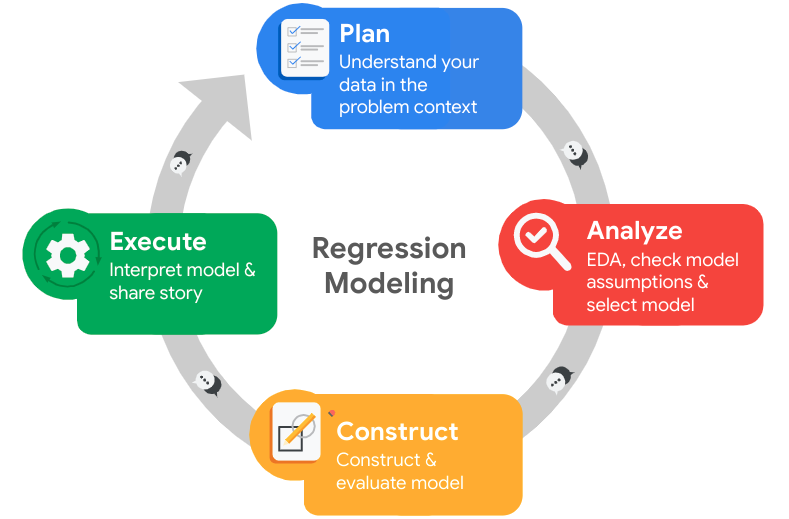

## **Pace: Plan**

Considere las preguntas de su Documento de Estrategia PACE para reflexionar sobre la etapa de planificación.

En esta etapa, considere lo siguiente:

### Comprender el escenario y el problema del negocio.

El departamento de RR. HH. de Salifort Motors quiere tomar iniciativas para mejorar la satisfacción de los empleados. Recopilaron datos de los empleados, pero ahora no saben qué hacer con ellos. Se refieren a usted como un profesional en análisis de datos y le piden que les brinde sugerencias basadas en su comprensión de los datos. Se plantean la siguiente pregunta: ¿qué es probable que haga que un empleado deje la empresa?

Sus objetivos en este proyecto son analizar los datos recopilados por el departamento de RR. HH. y crear un modelo que prediga si un empleado dejará la empresa o no.

Si puede predecir la probabilidad de que los empleados renuncien, podría identificar los factores que contribuyen a su salida. Dado que encontrar, entrevistar y contratar nuevos empleados es una tarea costosa y requiere mucho tiempo, aumentar la retención de personal será beneficioso para la empresa.

### Familiarícese con el conjunto de datos de RR.HH.

El conjunto de datos que utilizará en este laboratorio contiene 15 000 filas y 10 columnas para las variables que se enumeran a continuación.

**Nota:** No necesita descargar ningún dato para completar este laboratorio. Para obtener más información sobre los datos, consulte su fuente en [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).


Variable  |Description |Descripción |
-----|-----|-----| 
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|Nivel de satisfacción laboral informado por los empleados|
last_evaluation|Score of employee's last performance review [0&ndash;1]|1Puntuación de la última evaluación de desempeño del empleado|
number_project|Number of projects employee contributes to|Número de proyectos a los que contribuye el empleado|
average_monthly_hours|Average number of hours employee worked per month|Número promedio de horas trabajadas por empleado al mes|
time_spend_company|How long the employee has been with the company (years)|Cuánto tiempo lleva el empleado en la empresa (años)|
Work_accident|Whether or not the employee experienced an accident while at work|Si el empleado sufrió o no un accidente mientras trabajaba|
left|Whether or not the employee left the company|Si el empleado abandonó o no la empresa|
promotion_last_5years|Whether or not the employee was promoted in the last 5 years|Si el empleado fue ascendido o no en los últimos 5 años|
Department|The employee's department|El departamento del empleado|
salary|The employee's salary (U.S. dollars)|El salario del empleado (dólares estadounidenses)|

### Reflexione sobre estas preguntas a medida que completa la etapa de planificación.

* ¿Quiénes son las partes interesadas en este proyecto?
- ¿Qué intenta resolver o lograr?
- ¿Cuáles son sus observaciones iniciales al explorar los datos?
- ¿Qué recursos utiliza al completar esta etapa? (Asegúrese de incluir los enlaces).
- ¿Tiene alguna consideración ética en esta etapa?

## Paso 1. Importaciones

* Importar paquetes
* Cargar conjunto de datos

### Importar paquetes

In [1]:
# Importar paquetes
### YOUR CODE HERE ### 

# Para manipulación de datos
import numpy as np
import pandas as pd

# Para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Para mostrar todas las columnas en marcos de datos
pd.set_option('display.max_columns', None)

# Para modelado de datos
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Para métricas y funciones útiles
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# Para guardar modelos
import pickle

### Cargar conjunto de datos

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Cargar un conjunto de datos en un marco de datos
### YOUR CODE HERE ### 
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Mostrar las primeras filas del marco de datos
### YOUR CODE HERE ### 
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Paso 2. Exploración de datos (EDA inicial y limpieza de datos)


- Comprenda sus variables
- Limpie su conjunto de datos (datos faltantes, datos redundantes, valores atípicos)

### Recopilar información básica sobre los datos

In [3]:
# Recopilar información básica sobre los datos
### YOUR CODE HERE ### 
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Recopilar estadísticas descriptivas sobre los datos

In [4]:
# Recopilar estadísticas descriptivas sobre los datos
### YOUR CODE HERE ### 
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Cambiar el nombre de las columnas

Como paso de limpieza de datos, renombre las columnas según sea necesario. Estandarice los nombres de las columnas para que todos estén en formato `snake_case`, corrija los nombres de columna mal escritos y concéntrelos según sea necesario.

In [5]:
# Mostrar todos los nombres de las columnas
### YOUR CODE HERE ### 
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Cambie el nombre de las columnas según sea necesario
### YOUR CODE HERE ### 
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})

# Mostrar todos los nombres de columnas después de la actualización
### YOUR CODE HERE ### 
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Comprobar valores faltantes

Verifique si faltan valores en los datos.

In [7]:
# Comprobar valores faltantes
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

There are no missing values in the data.

### Verificar duplicados

Compruebe si hay entradas duplicadas en los datos.

In [8]:
# Buscar duplicados
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

3008 filas contienen duplicados. Esto representa el 20 % de los datos.

In [9]:
# Inspeccione algunas filas que contengan duplicados según sea necesario
### YOUR CODE HERE ###
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


El resultado anterior muestra las primeras cinco ocurrencias de filas duplicadas más abajo en el marco de datos. ¿Qué probabilidad hay de que sean entradas legítimas? En otras palabras, ¿qué tan plausible es que dos empleados hayan reportado exactamente la misma respuesta para cada columna?

Se podría realizar un análisis de verosimilitud aplicando el teorema de Bayes y multiplicando las probabilidades de encontrar cada valor en cada columna, pero esto no parece necesario. Con varias variables continuas en 10 columnas, parece muy improbable que estas observaciones sean legítimas. Se puede proceder omitiéndolas.

In [10]:
# Eliminar duplicados y guardar el marco de datos resultante en una nueva variable según sea necesario
### YOUR CODE HERE ###
df1 = df0.drop_duplicates(keep='first')

# Mostrar las primeras filas del nuevo marco de datos según sea necesario
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Comprobar valores atípicos

Comprobar si hay valores atípicos en los datos.

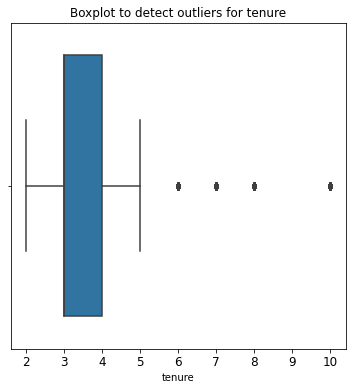

In [11]:
# Cree un diagrama de caja para visualizar la distribución de la permanencia y detectar valores atípicos
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()

El diagrama de caja anterior muestra que hay valores atípicos en la variable `tenure «antigüedad»`.

Sería útil investigar cuántas filas de los datos contienen valores atípicos en la columna `tenure «antigüedad»`.

In [12]:
# Determinar el número de filas que contienen valores atípicos
### YOUR CODE HERE ###

# Calcular el valor del percentil 25 en `tenure`
percentile25 = df1['tenure'].quantile(0.25)

# Calcular el valor del percentil 75 en `tenure`
percentile75 = df1['tenure'].quantile(0.75)

# Calcular el rango intercuartil en `tenure`
iqr = percentile75 - percentile25

# Define el límite superior y el límite inferior para valores no atípicos en `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Límite inferior:", lower_limit)
print("Límite superior:", upper_limit)

# Identificar un subconjunto de datos que contengan valores atípicos en `tenure`
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

# Cuente cuántas filas en los datos contienen valores atípicos en `tenure`
print("Número de filas en los datos que contienen valores atípicos en `tenure` (antigüedad):", len(outliers))

Límite inferior: 1.5
Límite superior: 5.5
Número de filas en los datos que contienen valores atípicos en `tenure` (antigüedad): 824


Ciertos tipos de modelos son más sensibles a los valores atípicos que otros. Al construir su modelo, considere si es necesario eliminar estos valores atípicos según el tipo de modelo que decida utilizar.

# pAce: Etapa analizar

- Realizar EDA (analizar relaciones entre variables)

💭 
### Reflexione sobre estas preguntas a medida que completa la etapa de análisis.

- ¿Qué observaste sobre las relaciones entre las variables?
- ¿Qué observaste sobre las distribuciones de los datos?
- ¿Qué transformaciones realizaste con tus datos? ¿Por qué tomaste esas decisiones?
- ¿Cuáles son algunos de los propósitos del análisis de datos extraídos (EDA) antes de construir un modelo predictivo?
- ¿Qué recursos utilizas al completar esta etapa? (Asegúrate de incluir los enlaces).
- ¿Tienes alguna consideración ética en esta etapa?

## Paso 2. Exploración de datos (Continuar con EDA)

Comience por comprender cuántos empleados se fueron y qué porcentaje de todos los empleados representa esta cifra.

In [13]:
# Obtenga números de personas que se fueron y las que se quedaron
### YOUR CODE HERE ###
print(df1['left'].value_counts())
print()

# Obtenga porcentajes de personas que se fueron frente a las que se quedaron
### YOUR CODE HERE ###
print(df1['left'].value_counts(normalize=True))

0    10000
1     1991
Name: left, dtype: int64

0    0.833959
1    0.166041
Name: left, dtype: float64


### Visualizaciones de datos

Ahora, examine las variables que le interesan y cree gráficos para visualizar las relaciones entre las variables en los datos.

Podría empezar creando un diagrama de cajas apiladas que muestre las distribuciones de `average_monthly_hours (promedio_horas_mensuales)` para `number_project (número_proyecto)`, comparando las distribuciones de los empleados que se quedaron con las de los que se marcharon.

Los diagramas de cajas son muy útiles para visualizar distribuciones dentro de los datos, pero pueden ser engañosos si no se tiene en cuenta el tamaño de las muestras que representan. Por lo tanto, también podría trazar un histograma apilado para visualizar la distribución de `number_project (número_proyecto)` para los empleados que se quedaron y los que se marcharon.

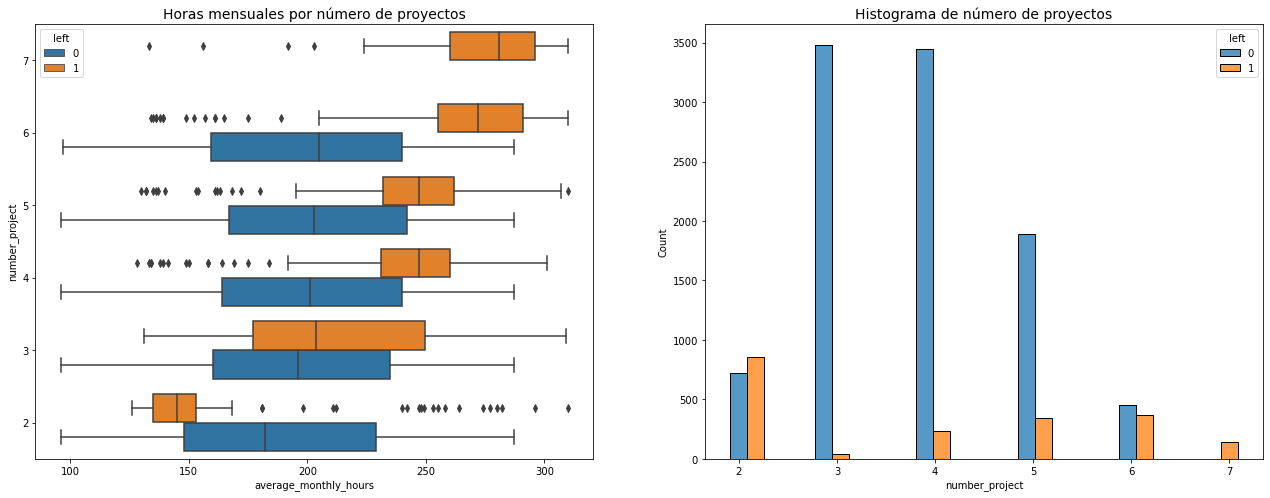

In [14]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###

# Establecer figura y ejes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Cree un diagrama de caja que muestre las distribuciones de `average_monthly_hours` para `number_project`, comparando a los empleados que se quedaron con los que se fueron
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Horas mensuales por número de proyectos', fontsize='14')

# Crear un histograma que muestre la distribución de `number_project`, comparando a los empleados que se quedaron con los que se fueron
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Histograma de número de proyectos', fontsize='14')

# Mostrar los cuadros
plt.show()

Podría ser natural que quienes trabajan en más proyectos también trabajen más horas. Este parece ser el caso, ya que la media de horas de cada grupo (permanencia y salida) aumenta con el número de proyectos trabajados. Sin embargo, algunos aspectos destacan en este gráfico.

1. Hay dos grupos de empleados que dejaron la empresa: (A) aquellos que trabajaron considerablemente menos que sus compañeros con el mismo número de proyectos, y (B) aquellos que trabajaron mucho más. Es posible que los del grupo A hayan sido despedidos. También es posible que este grupo incluya empleados que ya habían dado su aviso y se les asignaron menos horas porque ya estaban a punto de irse. En el caso del grupo B, es razonable inferir que probablemente renunciaron. Es probable que los del grupo B contribuyeran significativamente a los proyectos en los que trabajaron; podrían haber sido los que más contribuyeron a sus proyectos.

2. Todos los empleados con siete proyectos abandonaron la empresa, y el rango intercuartil de este grupo y de quienes abandonaron la empresa con seis proyectos fue de aproximadamente 255 a 295 horas al mes, mucho mayor que el de cualquier otro grupo.

3. El número óptimo de proyectos en los que los empleados pueden trabajar parece ser de 3 a 4. La proporción de abandonos/permanencias es muy baja para estos grupos.

4. Si se asume una semana laboral de 40 horas y dos semanas de vacaciones al año, el promedio de horas de trabajo al mes de los empleados que trabajan de lunes a viernes es de 50 semanas * 40 horas semanales / 12 meses = 166,67 horas al mes. Esto significa que, salvo los empleados que trabajaron en dos proyectos, todos los grupos, incluso los que no dejaron la empresa, trabajaron considerablemente más horas. Parece que los empleados están sobrecargados de trabajo.

A continuación, se podría confirmar que todos los empleados con siete proyectos se marcharon.

In [15]:
# Obtenga recuentos de valores de permanencia/salida de empleados con 7 proyectos
df1[df1['number_project']==7]['left'].value_counts()

1    145
Name: left, dtype: int64

Esto confirma que todos los empleados con 7 proyectos se marcharon.

A continuación, podría comparar el promedio de horas mensuales con los niveles de satisfacción.

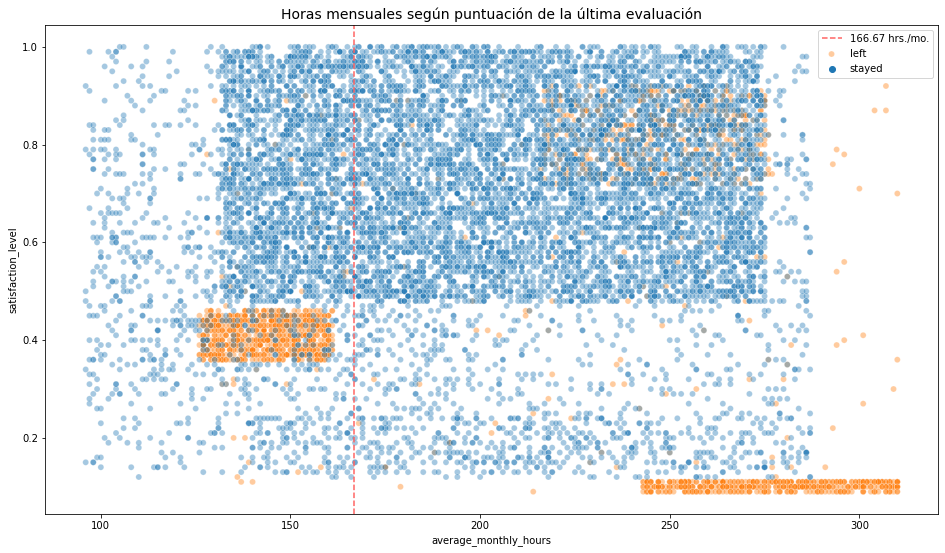

In [16]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###

# Crear un diagrama de dispersión de `average_monthly_hours` versus `satisfaction_level`, comparando a los empleados que se quedaron con los que se fueron
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Horas mensuales según puntuación de la última evaluación', fontsize='14');

El diagrama de dispersión anterior muestra que había un grupo considerable de empleados que trabajaban entre 240 y 315 horas al mes. 315 horas al mes equivalen a más de 75 horas semanales durante todo un año. Es probable que esto se deba a que sus niveles de satisfacción eran cercanos a cero.

El gráfico también muestra otro grupo de personas que se marcharon, quienes tenían un horario laboral más normal. Aun así, su satisfacción era de tan solo un 0,4. Es difícil especular sobre el motivo de su marcha. Es posible que se sintieran presionados a trabajar más, considerando que muchos de sus compañeros trabajaban más. Y esa presión podría haber reducido sus niveles de satisfacción.

Finalmente, hay un grupo que trabajaba entre 210 y 280 horas al mes, y cuyos niveles de satisfacción oscilaban entre 0,7 y 0,9.

Observe la extraña forma de las distribuciones. Esto indica manipulación o síntesis de datos.

Para la próxima visualización, podría ser interesante visualizar los niveles de satisfacción por antigüedad.

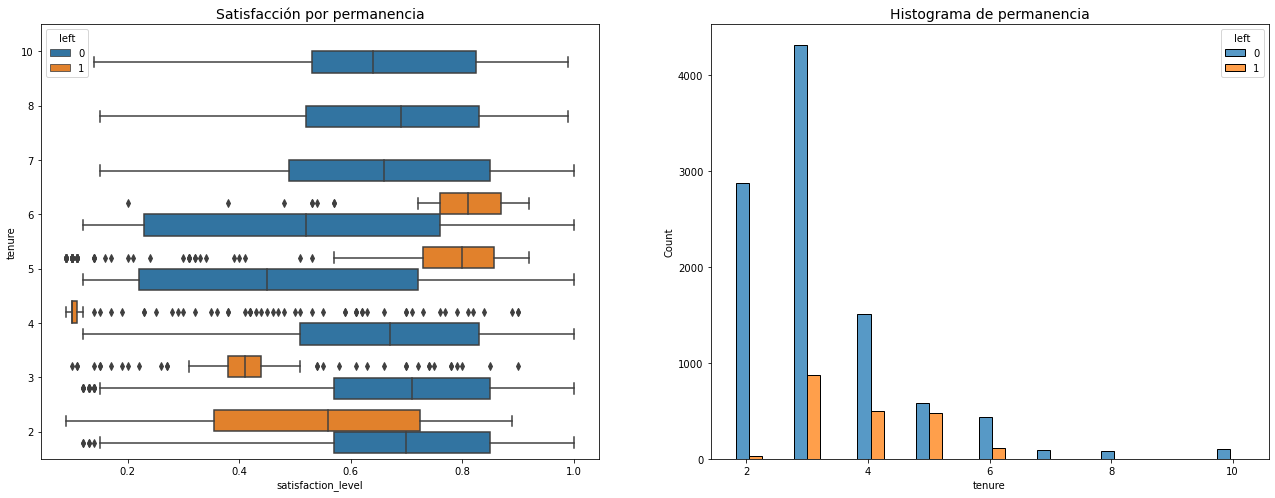

In [17]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###

# Establecer figura y ejes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Cree un diagrama de caja que muestre las distribuciones de `satisfaction_level` por antigüedad, comparando a los empleados que se quedaron con los que se fueron.
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfacción por permanencia', fontsize='14')

# Crear un histograma que muestre la distribución de la permanencia, comparando a los empleados que se quedaron con los que se fueron.
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Histograma de permanencia', fontsize='14')

plt.show();

Este gráfico ofrece muchas observaciones.
- Los empleados que se marcharon se dividen en dos categorías generales: empleados insatisfechos con menor antigüedad y empleados muy satisfechos con una antigüedad media.
- Los empleados con cuatro años de servicio que se marcharon parecen tener un nivel de satisfacción inusualmente bajo. Si es posible, conviene investigar los cambios en la política de la empresa que podrían haber afectado específicamente a los empleados que se marcharon durante los cuatro años.
- Los empleados con mayor antigüedad no se marcharon. Sus niveles de satisfacción coincidieron con los de los empleados más nuevos que se quedaron.
- El histograma muestra que hay relativamente pocos empleados con mayor antigüedad. Es posible que sean los empleados de mayor rango y mejor remunerados.

Como siguiente paso en el análisis de los datos, se podrían calcular las puntuaciones media y mediana de satisfacción de los empleados que se marcharon y de los que no.

In [18]:
# Calcular las puntuaciones medias y medianas de satisfacción de los empleados que se fueron y de los que se quedaron.
df1.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


Como era de esperar, la media y la mediana de satisfacción de los empleados que se marcharon son inferiores a las de los que se quedaron. Curiosamente, entre los empleados que se quedaron, la media de satisfacción parece estar ligeramente por debajo de la mediana. Esto indica que los niveles de satisfacción de quienes se quedaron podrían estar sesgados hacia la izquierda.

A continuación, se podrían examinar los niveles salariales para diferentes periodos de empleo.

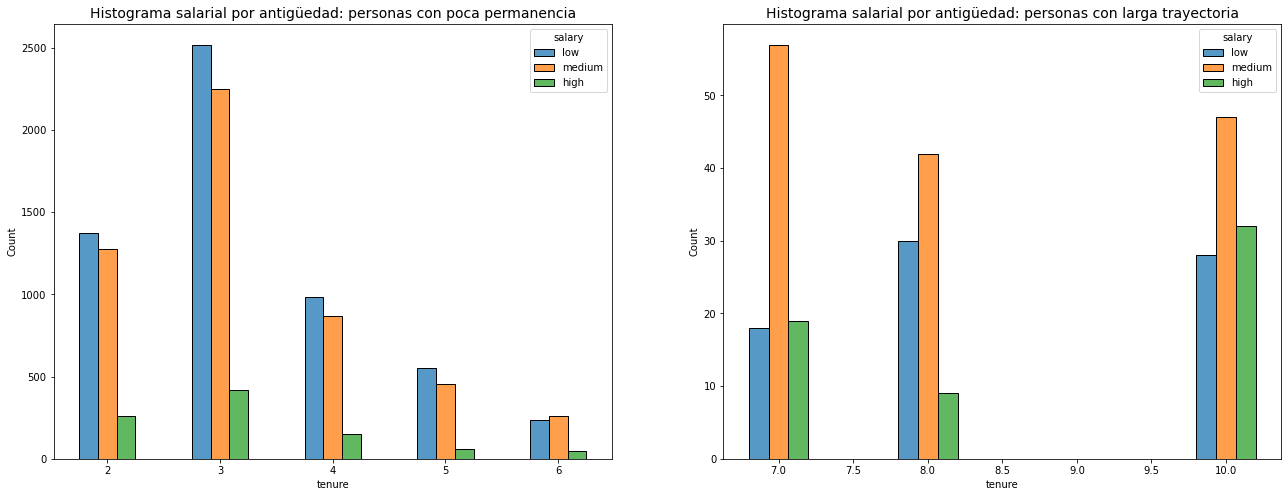

In [19]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###

# Establecer figura y ejes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Definir empleados con corta permanencia
tenure_short = df1[df1['tenure'] < 7]

# Definir empleados con larga trayectoria
tenure_long = df1[df1['tenure'] > 6]

# Trazar un histograma de corta duración
sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Histograma salarial por antigüedad: personas con poca permanencia', fontsize='14')

# Trazar un histograma de larga duración
sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Histograma salarial por antigüedad: personas con larga trayectoria', fontsize='14');

Los gráficos anteriores muestran que los empleados con mayor antigüedad no estaban compuestos desproporcionadamente por empleados con salarios más altos.

A continuación, podría explorar si existe una correlación entre trabajar muchas horas y obtener altas calificaciones en las evaluaciones. Podría crear un diagrama de dispersión de `promedio_de_horas_mensuales <average_monthly_hours>` frente a `última_evaluación <last_evaluation>`.

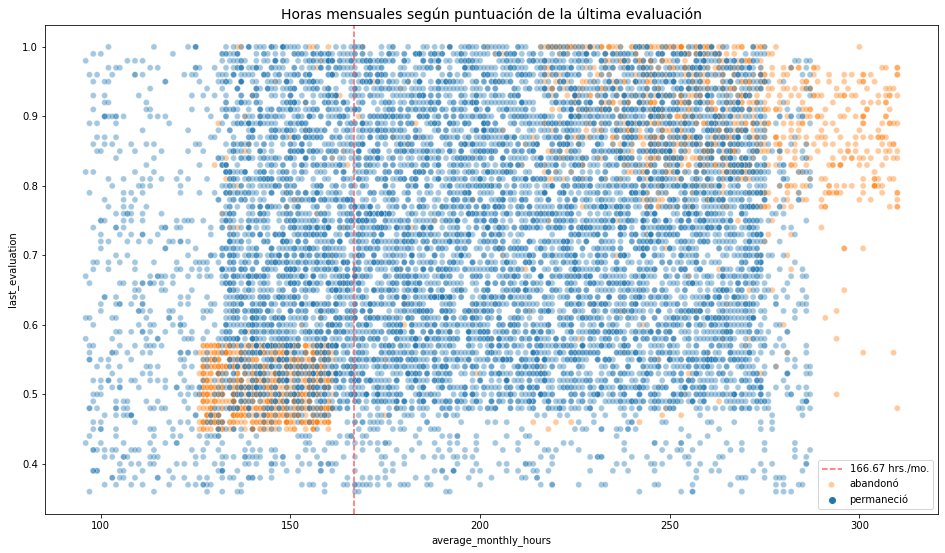

In [20]:
# Crea un gráfico según sea necesario 
### YOUR CODE HERE ###

# Crear un diagrama de dispersión de `average_monthly_hours` versus `last_evaluation`
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'abandonó', 'permaneció'])
plt.title('Horas mensuales según puntuación de la última evaluación', fontsize='14');

Del diagrama de dispersión anterior se pueden extraer las siguientes observaciones:
- El diagrama de dispersión indica dos grupos de empleados que se marcharon: empleados con exceso de trabajo que tuvieron un excelente rendimiento y empleados que trabajaron ligeramente por debajo del promedio mensual nominal de 166,67 horas, con puntuaciones de evaluación más bajas.
- Parece existir una correlación entre las horas trabajadas y la puntuación de evaluación.
- No hay un porcentaje alto de empleados en el cuadrante superior izquierdo de este diagrama; sin embargo, trabajar muchas horas no garantiza una buena puntuación de evaluación.
- La mayoría de los empleados de esta empresa trabajan bastante más de 167 horas al mes.

A continuación, podría examinar si los empleados que trabajaron muchas horas fueron ascendidos en los últimos cinco años.

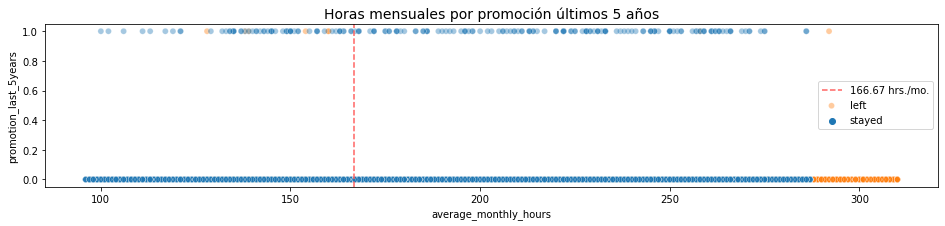

In [21]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###

# Crear un gráfico para examinar la relación entre `average_monthly_hours` y `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Horas mensuales por promoción últimos 5 años', fontsize='14');

El gráfico anterior muestra lo siguiente:
- Muy pocos empleados que fueron ascendidos en los últimos cinco años se marcharon.
- Muy pocos empleados que trabajaron más horas fueron ascendidos.
- Todos los empleados que se marcharon trabajaban más horas.

A continuación, podrías inspeccionar cómo se distribuyen los empleados que se marcharon entre los departamentos.

In [22]:
# Muestra los recuentos para cada departamento
df1["department"].value_counts()

sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: department, dtype: int64

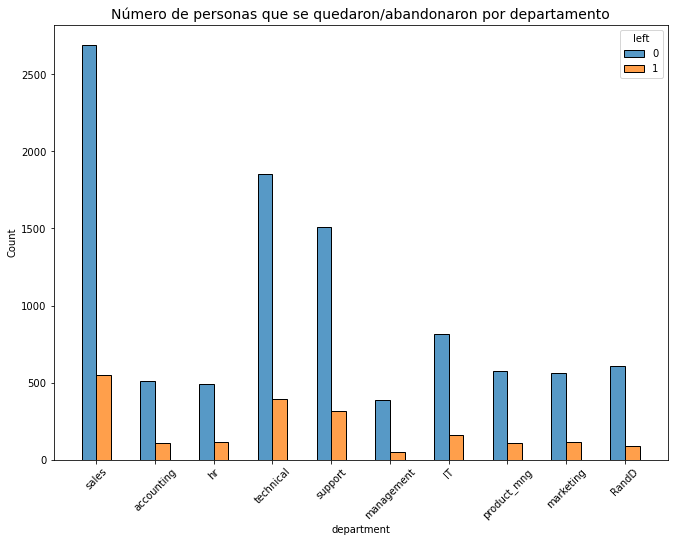

In [23]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###

# Cree un histograma apilado para comparar la distribución del departamento de empleados que se fueron con la de empleados que no lo hicieron.
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation='45')
plt.title('Número de personas que se quedaron/abandonaron por departamento', fontsize=14);


No parece haber ningún departamento con una proporción significativamente diferente de empleados que se marcharon y de los que se quedaron.

Por último, se podría comprobar si existen correlaciones sólidas entre las variables de los datos.

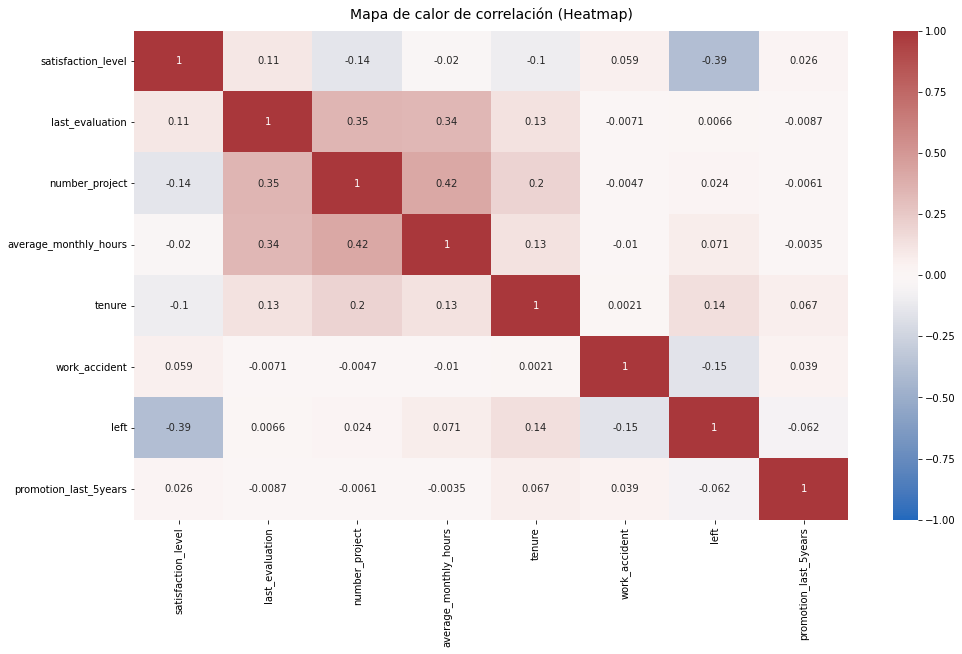

In [24]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###

# Trazar un mapa de calor de correlación
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Mapa de calor de correlación (Heatmap)', fontdict={'fontsize':14}, pad=12);

El mapa de calor de correlación confirma que la cantidad de proyectos, las horas mensuales y los puntajes de evaluación tienen alguna correlación positiva entre sí, y si un empleado se va o no está correlacionado negativamente con su nivel de satisfacción.

### hallazgos significativos

Parece que los empleados abandonan la empresa debido a una mala gestión. La salida se asocia a jornadas laborales más largas, numerosos proyectos y, en general, a una menor satisfacción. Puede ser ingratificante trabajar muchas horas y no recibir ascensos ni buenas calificaciones. Hay un grupo considerable de empleados en esta empresa que probablemente estén agotados. También parece que si un empleado lleva más de seis años en la empresa, tiende a no irse.

# paCe: Etapa de construcción

- Determinar qué modelos son los más apropiados
- Construir el modelo
- Confirmar los supuestos del modelo
- Evaluar los resultados del modelo para determinar su ajuste a los datos

🔎
## Recordar los supuestos del modelo

**Supuestos del modelo de regresión logística**
- La variable de resultado es categórica
- Las observaciones son independientes entre sí
- Sin multicolinealidad severa entre las variables X
- Sin valores atípicos extremos
- Relación lineal entre cada variable X y el logit de la variable de resultado
- Tamaño de muestra suficientemente grande

💭 
### Reflexione sobre estas preguntas a medida que completa la etapa de construcción.

- ¿Observa algo extraño?
- ¿Qué variables independientes eligió para el modelo y por qué?
- ¿Se cumplen todos los supuestos?
- ¿Qué tan bien se ajusta su modelo a los datos?
- ¿Puede mejorarlo? ¿Hay algo que cambiaría del modelo?
- ¿Qué recursos utiliza al completar esta etapa? (Asegúrese de incluir los enlaces).
- ¿Tiene alguna consideración ética en esta etapa?

## Paso 3. Construcción del modelo, Paso 4. Resultados y evaluación

- Ajustar un modelo que prediga la variable de resultado utilizando dos o más variables independientes.
- Verificar los supuestos del modelo.
- Evaluar el modelo.

### Identificar el tipo de tarea de predicción.

Su objetivo es predecir si un empleado deja la empresa, lo cual es una variable de resultado categórica. Por lo tanto, esta tarea implica una clasificación. Más específicamente, implica una clasificación binaria, ya que la variable de resultado «left» puede ser 1 (que indica que el empleado se fue) o 0 (que indica que el empleado no se fue).

### Identificar los tipos de modelos más apropiados para esta tarea.

Dado que la variable que se desea predecir (si un empleado deja la empresa) es categórica, se podría construir un modelo de regresión logística o un modelo de aprendizaje automático basado en árboles.

Por lo tanto, se podría proceder con uno de los dos enfoques siguientes. O, si se prefiere, se podrían implementar ambos y determinar cómo se comparan.

### Enfoque de modelado A: Modelo de regresión logística

Este enfoque cubre la implementación de la regresión logística.

#### Logistic regression

Tenga en cuenta que la regresión logística binomial es adecuada para la tarea porque implica una clasificación binaria.

Antes de dividir los datos, codifique las variables no numéricas. Hay dos: `department (departamento)` y `salary (salario)`.

`department (departamento)` es una variable categórica, lo que significa que puede simularla para el modelado.

`salary (salario)` también es categórica, pero es ordinal. Existe una jerarquía entre las categorías, por lo que es mejor no simular esta columna, sino convertir los niveles a números (0-2).

In [25]:
# Copiar el marco de datos (dataframe)
df_enc = df1.copy()

# Codifique la columna `salary <salario>` como una categoría numérica ordinal
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Codificación ficticia de la columna `department <departamento>`
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Mostrar el nuevo marco de datos (dataframe)
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


Crea un mapa de calor para visualizar la correlación entre las variables. Considera las variables entre las que te interesa examinar las correlaciones.

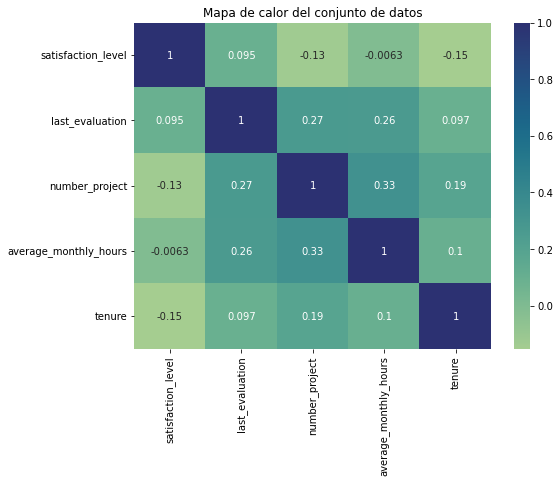

In [26]:
# Cree un mapa de calor <heatmap > para visualizar cómo se correlacionan las variables
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Mapa de calor del conjunto de datos')
plt.show()

Cree un gráfico de barras apiladas para visualizar la cantidad de empleados en todo el departamento, comparando aquellos que se fueron con aquellos que no lo hicieron.

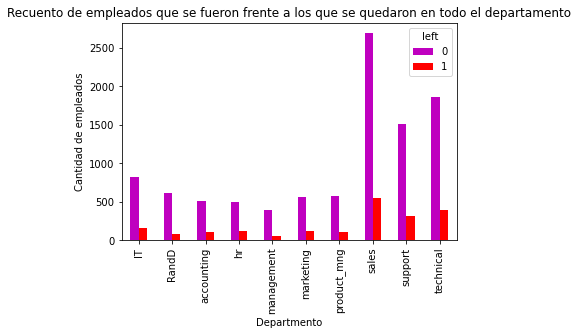

In [27]:
# Cree un diagrama de barras apiladas para visualizar la cantidad de empleados en el departamento, comparando a los que se fueron con los que no.
# En la leyenda, 0 (color morado) representa a los empleados que no se fueron, 1 (color rojo) representa a los empleados que se fueron.
pd.crosstab(df1['department'], df1['left']).plot(kind ='bar',color='mr')
plt.title('Recuento de empleados que se fueron frente a los que se quedaron en todo el departamento')
plt.ylabel('Cantidad de empleados')
plt.xlabel('Departmento')
plt.show()

Dado que la regresión logística es bastante sensible a los valores atípicos, sería una buena idea en esta etapa eliminar los valores atípicos en la columna `tenure "antigüedad"` que se identificaron anteriormente.

In [28]:
# Seleccione filas sin valores atípicos en `tenure` y guarde el marco de datos resultante en una nueva variable
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

# Mostrar las primeras filas del nuevo marco de datos
df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
5,0.41,0.50,2,153,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


Aísle la variable de resultado, que es la variable que desea que su modelo prediga.

In [29]:
# Aislar la variable de resultado
y = df_logreg['left']

# Mostrar las primeras filas de la variable de resultado
y.head() 

0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

Seleccione las características que desea usar en su modelo. Considere qué variables le ayudarán a predecir la variable de resultado, `left (abandono)`.

In [30]:
# Seleccione las características que desea utilizar en su modelo
X = df_logreg.drop('left', axis=1)

# Mostrar las primeras filas de las entidades seleccionadas
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,0,1,0,0
5,0.41,0.50,2,153,3,0,0,0,0,0,0,0,0,0,0,1,0,0


Divida los datos en un conjunto de entrenamiento y uno de prueba. No olvide estratificar según los valores de `y`, ya que las clases no están balanceadas.

In [31]:
# Dividir los datos en un conjunto de entrenamiento y un conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Construya un modelo de regresión logística y ajústelo al conjunto de datos de entrenamiento.

In [32]:
# Construya un modelo de regresión logística y ajústelo al conjunto de datos de entrenamiento
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)

Pruebe el modelo de regresión logística: utilice el modelo para hacer predicciones en el conjunto de prueba.

In [33]:
# Utilice el modelo de regresión logística para obtener predicciones en el conjunto de prueba
y_pred = log_clf.predict(X_test)

Cree una matriz de confusión para visualizar los resultados del modelo de regresión logística.

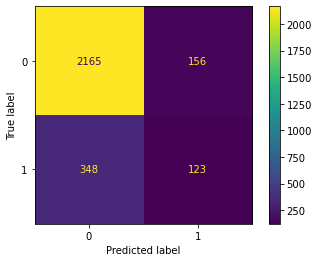

In [34]:
# Calcular valores para la matriz de confusión
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Crear visualización de la matriz de confusión
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)

# Matriz de confusión de la trama
log_disp.plot(values_format='')

# Mostrar gráfico
plt.show()

El cuadrante superior izquierdo muestra el número de verdaderos negativos.
El cuadrante superior derecho muestra el número de falsos positivos.
El cuadrante inferior izquierdo muestra el número de falsos negativos.
El cuadrante inferior derecho muestra el número de verdaderos positivos.

Verdaderos negativos: Número de personas que no abandonaron el estudio y que el modelo predijo con precisión.

Falsos positivos: Número de personas que no abandonaron el estudio y que el modelo predijo incorrectamente.

Falsos negativos: Número de personas que abandonaron el estudio y que el modelo predijo incorrectamente.

Verdaderos positivos: Número de personas que abandonaron el estudio y que el modelo predijo con precisión.

Un modelo perfecto arrojaría todos los verdaderos negativos y verdaderos positivos, sin falsos negativos ni falsos positivos.

Cree un informe de clasificación que incluya métricas de precisión, recuperación, puntuación f1 y exactitud para evaluar el rendimiento del modelo de regresión logística.

Verifique el balance de clases en los datos. En otras palabras, revise el recuento de valores en la columna `left`. Dado que se trata de una tarea de clasificación binaria, el balance de clases determina la forma en que interpreta las métricas de precisión.

In [35]:
df_logreg['left'].value_counts(normalize=True)

0    0.831468
1    0.168532
Name: left, dtype: float64

Hay una división aproximada del 83% al 17%. Por lo tanto, los datos no están perfectamente equilibrados, pero tampoco demasiado desequilibrados. Si el desequilibrio fuera mayor, podría ser conveniente remuestrear los datos para equilibrarlos mejor. En este caso, puede usar estos datos sin modificar el equilibrio de clases y continuar evaluando el modelo.

In [37]:
# Crear un informe de clasificación para el modelo de regresión logística

target_names = ['Se predijo que no se iría', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Se predijo que no se iría       0.86      0.93      0.90      2321
    Predicted would leave       0.44      0.26      0.33       471

                 accuracy                           0.82      2792
                macro avg       0.65      0.60      0.61      2792
             weighted avg       0.79      0.82      0.80      2792



El informe de clasificación anterior muestra que el modelo de regresión logística alcanzó una precisión del 79 %, una recuperación del 82 %, una puntuación f1 del 80 % (todos los promedios ponderados) y una exactitud del 82 %. Sin embargo, si lo más importante es predecir la salida de empleados, las puntuaciones son significativamente más bajas.

### Enfoque de modelado B: Modelo basado en árboles

Este enfoque cubre la implementación del árbol de decisiones y el bosque aleatorio.

Aislar la variable de resultado.

In [38]:
# Aislar la variable de resultado
y = df_enc['left']

# Mostrar las primeras filas de `y`
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

Seleccione las características.

In [39]:
# Seleccione las características
X = df_enc.drop('left', axis=1)

# Mostrar las primeras filas de `X`
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,0,1,0,0


Divida los datos en conjuntos de entrenamiento, validación y prueba.

In [40]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

#### Árbol de decisiones - Ronda 1

Construya un modelo de árbol de decisiones y configure una búsqueda de cuadrícula validada cruzada para buscar exhaustivamente los mejores parámetros del modelo.

In [41]:
# Instanciar modelo
tree = DecisionTreeClassifier(random_state=0)

# Asignar un diccionario de hiperparámetros para buscar
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Asignar un diccionario de métricas de puntuación para capturar
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Crear una instancia de GridSearch
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

Ajuste el modelo de árbol de decisión a los datos de entrenamiento.

In [42]:
%%time
tree1.fit(X_train, y_train)

CPU times: user 2.87 s, sys: 45.5 ms, total: 2.91 s
Wall time: 2.91 s


GridSearchCV(cv=4, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=None,
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                

Identificar los valores óptimos para los parámetros del árbol de decisión.

In [ ]:
# Verifique los mejores parámetros
tree1.best_params_

Identifique la mejor puntuación AUC lograda por el modelo de árbol de decisión en el conjunto de entrenamiento.

In [43]:
# Consulte la mejor puntuación AUC en CV
tree1.best_score_

0.969819392792457

Esta es una puntuación AUC sólida, lo que demuestra que este modelo puede predecir con gran precisión la salida de los empleados.

A continuación, puede crear una función que le ayude a extraer todas las puntuaciones de la búsqueda en la cuadrícula. 

In [44]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Argumentos:
        model_name (string): cómo desea que se llame el modelo en la tabla de salida
        model_object: un objeto GridSearchCV adecuado
        metric (string): precision, recall, f1, accuracy, or auc
  
    Devuelve un df de pandas con las puntuaciones F1, recuperación, precisión, exactitud y auc para el modelo 
    con la mejor puntuación "métrica" ​​media en todos los pliegues de validación.  
    '''

    # Crear un diccionario que asigne la métrica de entrada al nombre de la métrica real en GridSearchCV
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Aísle la fila del df con la puntuación máxima (métrica)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extraiga la precisión, exactitud, recuperación y puntuación f1 de esa fila
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Crear tabla de resultados
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })
  
    return table

Utilice la función que acaba de definir para obtener todas las puntuaciones de la búsqueda en cuadrícula.

In [45]:
# Obtenga todas las puntuaciones de CV
tree1_cv_results = make_results('CV del árbol de decisión', tree1, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,auc
0,CV del árbol de decisión,0.914552,0.916949,0.915707,0.971978,0.969819


Todas estas puntuaciones del modelo de árbol de decisión son indicadores sólidos de un buen rendimiento del modelo.

Recuerde que los árboles de decisión pueden ser vulnerables al sobreajuste, y los bosques aleatorios lo evitan incorporando múltiples árboles para realizar predicciones. A continuación, podría construir un modelo de bosque aleatorio.

#### Bosque aleatorio - Ronda 1

Construya un modelo de bosque aleatorio y configure una búsqueda de cuadrícula validada cruzada para buscar de forma exhaustiva los mejores parámetros del modelo.

In [46]:
# Instanciar modelo
rf = RandomForestClassifier(random_state=0)

# Asignar un diccionario de hiperparámetros para buscar
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Asignar un diccionario de métricas de puntuación para capturar
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Crear una instancia de GridSearch
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

Ajuste el modelo de bosque aleatorio a los datos de entrenamiento.

In [47]:
%%time
rf1.fit(X_train, y_train) # --> tiempo aproximado: ~10min

CPU times: user 9min 12s, sys: 1.87 s, total: 9min 14s
Wall time: 9min 14s


GridSearchCV(cv=4, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,...
                                              verbose=0, warm_start=False),
             iid='deprecated', n_jo

Especifique la ruta donde desea guardar su modelo.

In [ ]:
# Define una ruta a la carpeta donde quieres guardar el modelo
path = './models/'

Define funciones para conservar el modelo y leerlo.

In [49]:
def write_pickle(path, model_object, save_as:str):
    '''
    In: 
        path:         Ruta de la carpeta donde desea guardar el pickle
        model_object: un modelo que quieres en pickle
        save_as:      nombre de archivo para cómo desea guardar el modelo

    Out: Una llamada para guardar el modelo en la carpeta indicada
    '''    

    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [50]:
def read_pickle(path, saved_model_name:str):
    '''
    In: 
        path:             Ruta de la carpeta desde donde desea leer
        saved_model_name: Nombre del archivo del modelo pickled que desea leer

    Out: 
        model: el modelo encurtido
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

Utilice las funciones definidas anteriormente para guardar el modelo en un archivo pickle y luego leerlo.

In [51]:
# Escribir pickle
write_pickle(path, rf1, 'hr_rf1')

In [52]:
# Leer pickle
rf1 = read_pickle(path, 'hr_rf1')

Identifique la mejor puntuación AUC lograda por el modelo de bosque aleatorio en el conjunto de entrenamiento.

In [53]:
# Consulte la mejor puntuación AUC en CV
rf1.best_score_

0.9804250949807172

Identificar los valores óptimos para los parámetros del modelo de bosque aleatorio.

In [54]:
# Comprueba los mejores parámetros
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

Recopile las puntuaciones de evaluación en el conjunto de entrenamiento para los modelos de árbol de decisiones y bosque aleatorio.

In [55]:
# Obtenga todas las puntuaciones de CV
rf1_cv_results = make_results('cv bosque aleatorio', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

                      model  precision    recall        F1  accuracy       auc
0  CV del árbol de decisión   0.914552  0.916949  0.915707  0.971978  0.969819
                 model  precision    recall        F1  accuracy       auc
0  cv bosque aleatorio   0.950023  0.915614  0.932467  0.977983  0.980425


Las puntuaciones de evaluación del modelo de bosque aleatorio son mejores que las del modelo de árbol de decisión, con la excepción de la recuperación (la puntuación de recuperación del modelo de bosque aleatorio es aproximadamente 0,001 menor, una cantidad insignificante). Esto indica que el modelo de bosque aleatorio supera en gran medida al modelo de árbol de decisión.

A continuación, puede evaluar el modelo final en el conjunto de prueba.

Define una función que obtenga todos los puntajes de las predicciones de un modelo.

In [56]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generar una tabla de puntuaciones de pruebas.

    In: 
        model_name (string):  Cómo desea que se nombre su modelo en la tabla de salida
        model:                Un objeto GridSearchCV adecuado
        X_test_data:          Matriz numpy de datos de X_test
        y_test_data:          Matriz numpy de datos de y_test

    Out: pandas df de precisión, recuperación, f1, exactitud y puntuaciones AUC para su modelo
    '''

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table

Ahora use el modelo con mejor rendimiento para predecir en el conjunto de prueba.

In [57]:
# Obtenga predicciones sobre los datos de prueba
rf1_test_scores = get_scores('prueba de bosque aleatorio1', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,prueba de bosque aleatorio1,0.964211,0.919679,0.941418,0.980987,0.956439


Los resultados de las pruebas son muy similares a los de validación, lo cual es positivo. Este modelo parece ser sólido. Dado que este conjunto de pruebas solo se utilizó para este modelo, puede estar más seguro de que el rendimiento de su modelo con estos datos es representativo de su rendimiento con datos nuevos e inéditos.

#### Ingeniería de características

Podrías dudar de las altas puntuaciones de evaluación. Existe la posibilidad de que se produzca una fuga de datos. Esto ocurre cuando se utilizan datos para entrenar el modelo que no deberían usarse durante el entrenamiento, ya sea porque aparecen en los datos de prueba o porque no son los que se esperaría tener al implementar el modelo. Entrenar un modelo con datos filtrados puede generar una puntuación poco realista que no se replica en producción.

En este caso, es probable que la empresa no tenga registrados los niveles de satisfacción de todos sus empleados. También es posible que la columna `average_monthly_hours (promedio_de_horas_mensuales)` sea una fuente de fuga de datos. Si los empleados ya han decidido renunciar o la gerencia ya los ha identificado como personas a despedir, es posible que trabajen menos horas.

La primera ronda de modelos de árboles de decisión y bosques aleatorios incluyó todas las variables como características. Esta siguiente ronda incorporará ingeniería de características para construir modelos mejorados.

Podría continuar eliminando `satisfaction_level` y creando una nueva característica que capture aproximadamente si un empleado tiene exceso de trabajo. Podría llamar a esta nueva característica `overworked`. Será una variable binaria.

In [58]:
# Eliminar `satisfaction_level` y guardar el marco de datos resultante en una nueva variable
df2 = df_enc.drop('satisfaction_level', axis=1)

# Mostrar las primeras filas del nuevo marco de datos (dataframe)
df2.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [59]:
# Crear la columna `overworked (sobrecargado de trabajo)`. Por ahora, es idéntica al promedio de horas mensuales.
df2['overworked'] = df2['average_monthly_hours']

# Inspeccionar los valores promedio de horas mensuales máximos y mínimos
print('Horas máximas:', df2['overworked'].max())
print('Horas mínimas:', df2['overworked'].min())

Horas máximas: 310
Horas mínimas: 96


166,67 es aproximadamente el promedio de horas mensuales de alguien que trabaja 50 semanas al año, 5 días a la semana y 8 horas al día.

Se podría definir el exceso de trabajo como trabajar más de 175 horas al mes en promedio.

Para convertir la columna `overworked` en binaria, se podría reasignar la columna usando una máscara booleana.
- `df3['overworked'] > 175` crea una serie de valores booleanos, que consisten en `True` para cada valor > 175 y `False` para cada valor ≤ 175.
- `.astype(int)` convierte todos los valores `True` en `1` y todos los valores `False`» en `0`.

In [60]:
# Define `overworked` o "sobrecargado de trabajo" como trabajar más de 175 horas por semana.
df2['overworked'] = (df2['overworked'] > 175).astype(int)

# Mostrar las primeras filas de la nueva columna
df2['overworked'].head()

0    0
1    1
2    1
3    1
4    0
Name: overworked, dtype: int64

Eliminar la columna `average_monthly_hours`.

In [61]:
# Eliminar la columna the `average_monthly_hours`
df2 = df2.drop('average_monthly_hours', axis=1)

# Mostrar las primeras filas del marco de datos resultante
df2.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0.86,5,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
2,0.88,7,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
3,0.87,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
4,0.52,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0


Nuevamente, aísle las características y las variables objetivo.

In [62]:
# Aislar la variable de resultado
y = df2['left']

# Seleccione las características
X = df2.drop('left', axis=1)

Divida los datos en conjuntos de entrenamiento y prueba.

In [63]:
# Crear datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

#### Árbol de decisiones - Ronda 2

In [64]:
# Instanciar modelo
tree = DecisionTreeClassifier(random_state=0)

# Asignar un diccionario de hiperparámetros para buscar
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Asignar un diccionario de métricas de puntuación para capturar
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Crear una instancia de GridSearch
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [65]:
%%time
tree2.fit(X_train, y_train)

CPU times: user 2.31 s, sys: 414 µs, total: 2.31 s
Wall time: 2.31 s


GridSearchCV(cv=4, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=None,
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                

In [66]:
# Comprueba los mejores parámetros
tree2.best_params_

{'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 6}

In [67]:
# Consulte la mejor puntuación AUC en CV
tree2.best_score_

0.9586752505340426

Este modelo funciona muy bien, incluso sin niveles de satisfacción ni datos detallados de horas trabajadas.

A continuación, revise las demás puntuaciones.

In [68]:
# Obtenga todas las puntuaciones de CV
tree2_cv_results = make_results('árbol de decisión2 cv', tree2, 'auc')
print(tree1_cv_results)
print(tree2_cv_results)

                      model  precision    recall        F1  accuracy       auc
0  CV del árbol de decisión   0.914552  0.916949  0.915707  0.971978  0.969819
                   model  precision    recall        F1  accuracy       auc
0  árbol de decisión2 cv   0.856693  0.903553  0.878882  0.958523  0.958675


Algunas de las demás puntuaciones bajaron. Era de esperar, dado que se consideraron menos características en esta ronda del modelo. Aun así, las puntuaciones son muy buenas.

#### Bosque aleatorio - Ronda 2

In [69]:
# Instanciar modelo
rf = RandomForestClassifier(random_state=0)

# Asignar un diccionario de hiperparámetros para buscar
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Asignar un diccionario de métricas de puntuación para capturar
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Crear una instancia de GridSearch
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [70]:
%%time
rf2.fit(X_train, y_train) # --> Tiempo estimado: 7min 5s

CPU times: user 6min 55s, sys: 823 ms, total: 6min 56s
Wall time: 6min 56s


GridSearchCV(cv=4, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,...
                                              verbose=0, warm_start=False),
             iid='deprecated', n_jo

In [71]:
# Escribir pickle
write_pickle(path, rf2, 'hr_rf2')

In [72]:
# Leer in pickle
rf2 = read_pickle(path, 'hr_rf2')

In [73]:
# Comprueba los mejores parámetros
rf2.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [74]:
# Consulte la mejor puntuación AUC en CV
rf2.best_score_

0.9648100662833985

In [75]:
# Obtenga todas las puntuaciones de CV
rf2_cv_results = make_results('CV de bosque aleatorio2', rf2, 'auc')
print(tree2_cv_results)
print(rf2_cv_results)

                   model  precision    recall        F1  accuracy       auc
0  árbol de decisión2 cv   0.856693  0.903553  0.878882  0.958523  0.958675
                     model  precision    recall        F1  accuracy      auc
0  CV de bosque aleatorio2   0.866758  0.878754  0.872407  0.957411  0.96481


Nuevamente, las puntuaciones bajaron ligeramente, pero el bosque aleatorio funciona mejor que el árbol de decisión si se usa el AUC como métrica decisiva.

Califique ahora el modelo líder en el conjunto de prueba.

In [76]:
# Obtenga predicciones sobre los datos de prueba
rf2_test_scores = get_scores('prueba de bosque aleatorio2', rf2, X_test, y_test)
rf2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,prueba de bosque aleatorio2,0.870406,0.903614,0.8867,0.961641,0.938407


Este parece ser un modelo final estable y con buen rendimiento.

Dibuje una matriz de confusión para visualizar su precisión en las predicciones del conjunto de prueba.

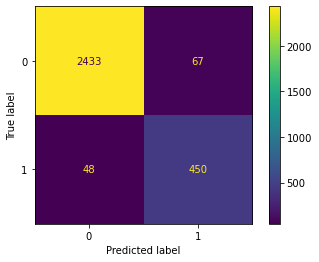

In [77]:
# Generar una matriz de valores para la matriz de confusión
preds = rf2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=rf2.classes_)

# Matriz de confusión de la trama
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rf2.classes_)
disp.plot(values_format='');

El modelo predice más falsos positivos que falsos negativos, lo que significa que algunos empleados podrían ser identificados como en riesgo de renunciar o ser despedidos, cuando en realidad no es así. Sin embargo, sigue siendo un modelo sólido.

Con fines exploratorios, podría ser útil inspeccionar las divisiones del modelo de árbol de decisión y las características más importantes del modelo de bosque aleatorio. 

#### Divisiones del árbol de decisión

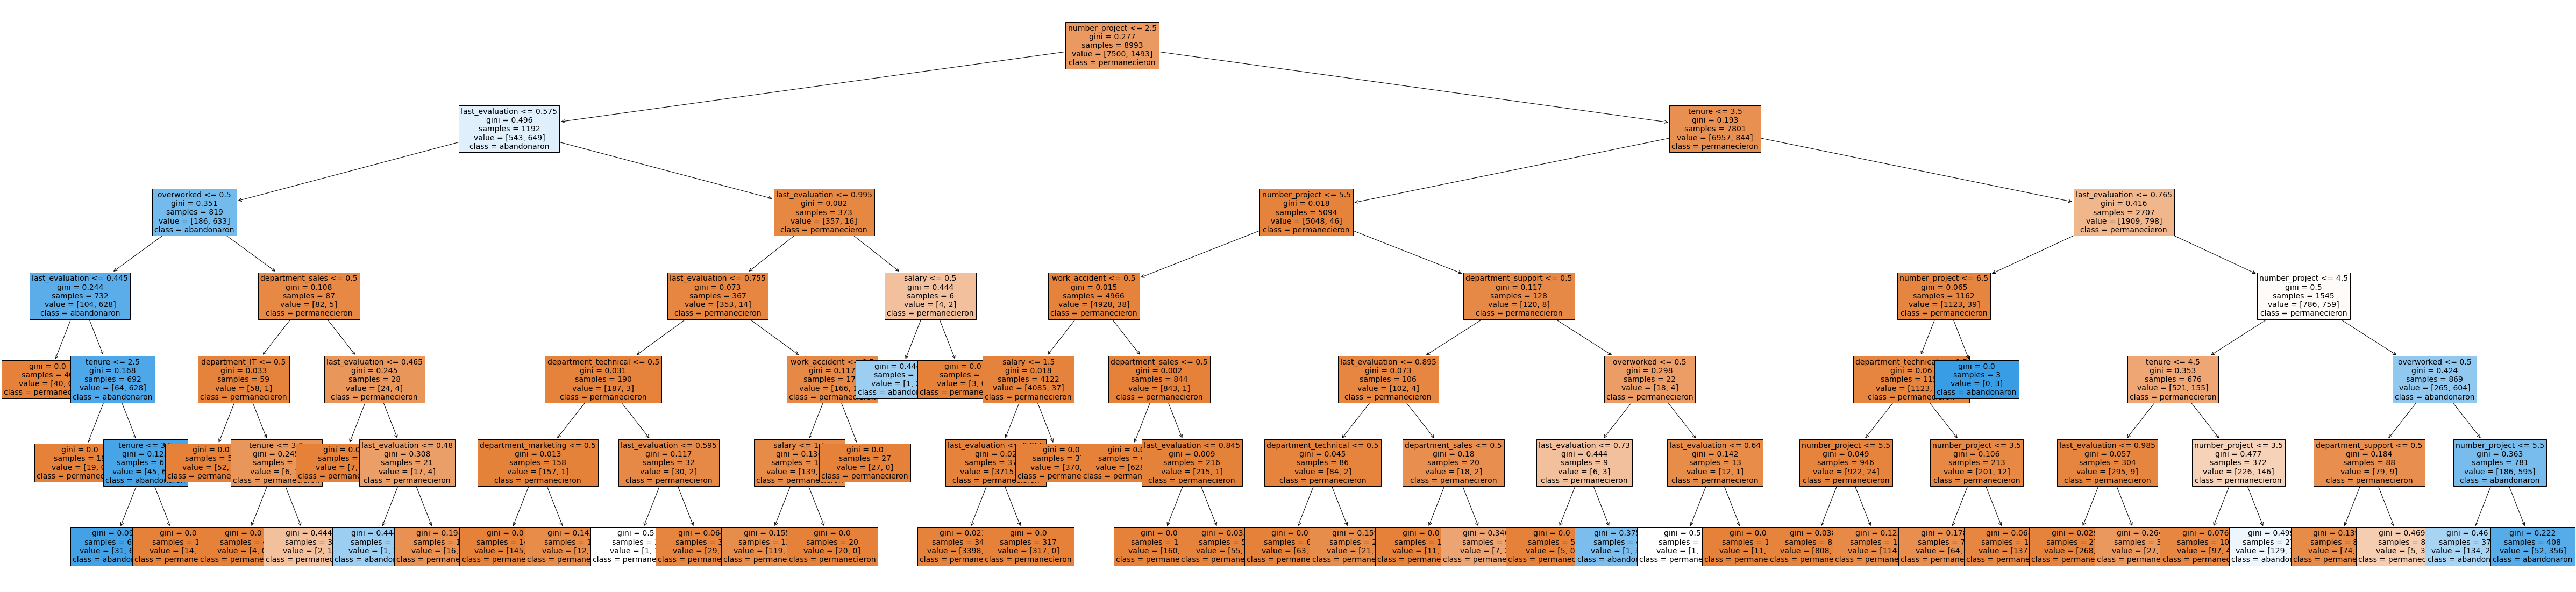

In [78]:
# Trazar el árbol
plt.figure(figsize=(85,20))
plot_tree(tree2.best_estimator_, max_depth=6, fontsize=14, feature_names=X.columns, 
          class_names={0:'permanecieron', 1:'abandonaron'}, filled=True);
plt.show()

Tenga en cuenta que puede hacer doble clic en la imagen del árbol para ampliarla e inspeccionar las divisiones.

#### Importancia de la característica del árbol de decisión

También puede obtener la importancia de las características a partir de árboles de decisión (consulte la [DecisionTreeClassifier scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_) para más detalles).

In [79]:
#tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_, columns=X.columns)
tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_, 
                                 columns=['gini_importance'], 
                                 index=X.columns
                                )
tree2_importances = tree2_importances.sort_values(by='gini_importance', ascending=False)

# Extraiga únicamente las características con importancias > 0
tree2_importances = tree2_importances[tree2_importances['gini_importance'] != 0]
tree2_importances

,gini_importance
last_evaluation,0.343958
number_project,0.343385
tenure,0.215681
overworked,0.093498
department_support,0.001142
salary,0.000910
department_sales,0.000607
department_technical,0.000418
work_accident,0.000183
department_IT,0.000139


Luego puede crear un gráfico de barras para visualizar la importancia de las características del árbol de decisión.

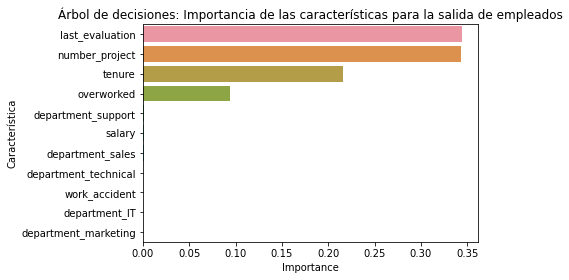

In [80]:
sns.barplot(data=tree2_importances, x="gini_importance", y=tree2_importances.index, orient='h')
plt.title("Árbol de decisiones: Importancia de las características para la salida de empleados", fontsize=12)
plt.ylabel("Característica")
plt.xlabel("Importance")
plt.show()

El diagrama de barras anterior muestra que, en este modelo de árbol de decisión, `last_evaluation`, `number_project`, `tenure` y `overworked` tienen la mayor importancia, en ese orden. Estas variables son las más útiles para predecir la variable de resultado, `left`.

#### Importancia de las características del bosque aleatorio

Ahora, grafica la importancia de las características del modelo de bosque aleatorio.

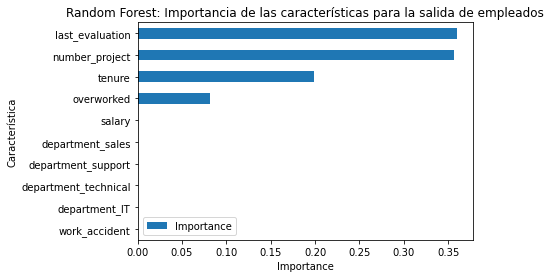

In [81]:
# Obtener características importantes
feat_impt = rf2.best_estimator_.feature_importances_

# Obtenga índices de las 10 características principales
ind = np.argpartition(rf2.best_estimator_.feature_importances_, -10)[-10:]

# Obtenga las etiquetas de las columnas de las 10 características principales
feat = X.columns[ind]

# Filtrar `feat_impt` para que conste de las 10 características más importantes
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance")

ax1.set_title("Random Forest: Importancia de las características para la salida de empleados", fontsize=12)
ax1.set_ylabel("Característica")
ax1.set_xlabel("Importance")

plt.show()

El gráfico anterior muestra que, en este modelo de bosque aleatorio, `last_evaluation`, `number_project`, `tenure` y `overworked` tienen la mayor importancia, en ese orden. Estas variables son las más útiles para predecir la variable de resultado, `left`, y son las mismas que utiliza el modelo de árbol de decisión.

# pacE: Etapa ejecutar

- Interpretar el rendimiento y los resultados del modelo
- Compartir las medidas prácticas con las partes interesadas

✏
## Métricas de evaluación de recuerdo

- El **AUC** es el área bajo la curva ROC; también se considera la probabilidad de que el modelo clasifique un ejemplo positivo aleatorio con mayor probabilidad que uno negativo aleatorio.
- La **Precisión** mide la proporción de puntos de datos predichos como Verdaderos que realmente lo son; es decir, la proporción de predicciones positivas que son verdaderos positivos.
- El **Recuerdo** mide la proporción de puntos de datos predichos como Verdaderos, de todos los puntos de datos que realmente son Verdaderos. En otras palabras, mide la proporción de positivos que se clasifican correctamente.
- La **Exactitud** mide la proporción de puntos de datos que se clasifican correctamente.
- La **puntuación F1** es una suma de la precisión y el recuerdo.

💭 
### Reflexione sobre estas preguntas al completar la etapa de ejecución.

- ¿Qué conclusiones clave surgieron de su(s) modelo(s)?
- ¿Qué recomendaciones de negocio propone con base en los modelos creados?
- ¿Qué recomendaciones potenciales le haría a su gerente/empresa?
- ¿Cree que su modelo podría mejorarse? ¿Por qué sí o por qué no? ¿Cómo?

- Con lo que sabe sobre los datos y los modelos que estaba utilizando, ¿qué otras preguntas podría plantearle al equipo?

- ¿Qué recursos utiliza al completar esta etapa? (Asegúrese de incluir los enlaces).
- ¿Tiene alguna consideración ética en esta etapa?

## Paso 4. Resultados y evaluación

- Interpretar el modelo
- Evaluar el rendimiento del modelo mediante métricas
- Preparar resultados, visualizaciones y pasos prácticos para compartir con las partes interesadas

### Resumen de los resultados del modelo

**Regresión logística**

El modelo de regresión logística alcanzó una precisión del 80 %, una recuperación del 83 %, una puntuación f1 del 80 % (todos los promedios ponderados) y una exactitud del 83 % en el conjunto de prueba.

**Aprendizaje automático basado en árboles**

Tras realizar la ingeniería de características, el modelo de árbol de decisión alcanzó un AUC del 93,8 %, una precisión del 87,0 %, una recuperación del 90,4 %, una puntuación f1 del 88,7 % y una exactitud del 96,2 % en el conjunto de prueba. El bosque aleatorio superó ligeramente el rendimiento del modelo de árbol de decisión. 

### Conclusión, Recomendaciones, Próximos Pasos

Los modelos y la importancia de las características extraídas de ellos confirman que los empleados de la empresa sufren sobrecarga de trabajo.

Para retener a los empleados, se podrían presentar las siguientes recomendaciones a las partes interesadas:

* Limite el número de proyectos en los que los empleados pueden trabajar.
* Considere ascender a empleados con al menos cuatro años de antigüedad en la empresa o investigue a fondo por qué los empleados con cuatro años de antigüedad están tan insatisfechos.
* Recompense a los empleados por trabajar más horas o no les exija que lo hagan.
* Si los empleados no están familiarizados con las políticas de pago de horas extra de la empresa, infórmeles al respecto. Si las expectativas sobre la carga de trabajo y el tiempo libre no son explícitas, aclárelas.
* Mantenga conversaciones con toda la empresa y dentro del equipo para comprender y abordar la cultura laboral de la empresa, de forma general y en contextos específicos.
* Las altas calificaciones en las evaluaciones no deben reservarse para los empleados que trabajan más de 200 horas al mes. Considere una escala proporcional para recompensar a los empleados que contribuyen más o se esfuerzan más.

**Próximos pasos**

Puede que aún esté justificado preocuparse por la fuga de datos. Sería prudente considerar cómo cambian las predicciones al eliminar `last_evaluation` de los datos. Es posible que las evaluaciones no se realicen con mucha frecuencia, en cuyo caso sería útil predecir la retención de empleados sin esta función. También es posible que la puntuación de la evaluación determine si un empleado se marcha o se queda, en cuyo caso podría ser útil realizar un cambio de estrategia e intentar predecir la puntuación de rendimiento. Lo mismo podría decirse de la puntuación de satisfacción.

Para otro proyecto, podría intentar crear un modelo de K-medias con estos datos y analizar los clústeres. Esto podría proporcionar información valiosa.

**Felicitaciones!** Has completado este laboratorio. Sin embargo, es posible que no veas una marca de verificación verde junto a este elemento en la plataforma de Coursera. Continúa con tu progreso independientemente de la marca de verificación. Simplemente haz clic en el icono de "Guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo se haya registrado.